In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
uploaded = files.upload()

Saving CO2 Emissions.csv to CO2 Emissions (1).csv


In [ ]:
import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("File loaded successfully!")

File loaded successfully!


In [ ]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
df.tail()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7384,VOLVO,XC90 T6 AWD,SUV - STANDARD,2.0,4,AS8,Z,12.2,8.7,10.7,26,248


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7385
Number of columns: 12


In [ ]:
print("Columns in dataset:")
for col in df.columns:
    print(col)

Columns in dataset:
Make
Model
Vehicle Class
Engine Size(L)
Cylinders
Transmission
Fuel Type
Fuel Consumption City (L/100 km)
Fuel Consumption Hwy (L/100 km)
Fuel Consumption Comb (L/100 km)
Fuel Consumption Comb (mpg)
CO2 Emissions(g/km)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [ ]:
df.describe(include='object')

,Make,Model,Vehicle Class,Transmission,Fuel Type
count,7385,7385,7385,7385,7385
unique,42,2053,16,27,5
top,FORD,F-150 FFV,SUV - SMALL,AS6,X
freq,628,32,1217,1324,3637


In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Make                                0.0
Model                               0.0
Vehicle Class                       0.0
Engine Size(L)                      0.0
Cylinders                           0.0
Transmission                        0.0
Fuel Type                           0.0
Fuel Consumption City (L/100 km)    0.0
Fuel Consumption Hwy (L/100 km)     0.0
Fuel Consumption Comb (L/100 km)    0.0
Fuel Consumption Comb (mpg)         0.0
CO2 Emissions(g/km)                 0.0
dtype: float64


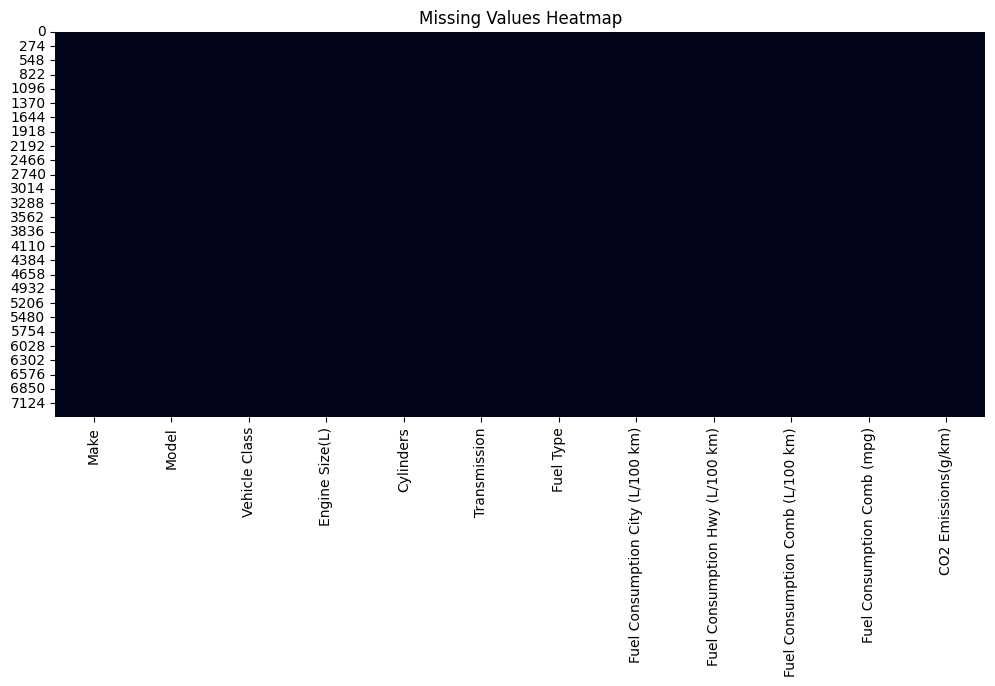

In [ ]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1103


In [ ]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (6282, 12)


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']

Categorical columns:
['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']


In [ ]:
target_candidates = [
    col for col in df.columns
    if 'co2' in col.lower() and 'emission' in col.lower()
]

print(target_candidates)

['CO2 Emissions(g/km)']


In [ ]:
target_col = target_candidates[0]

print("Target column:", target_col)

Target column: CO2 Emissions(g/km)


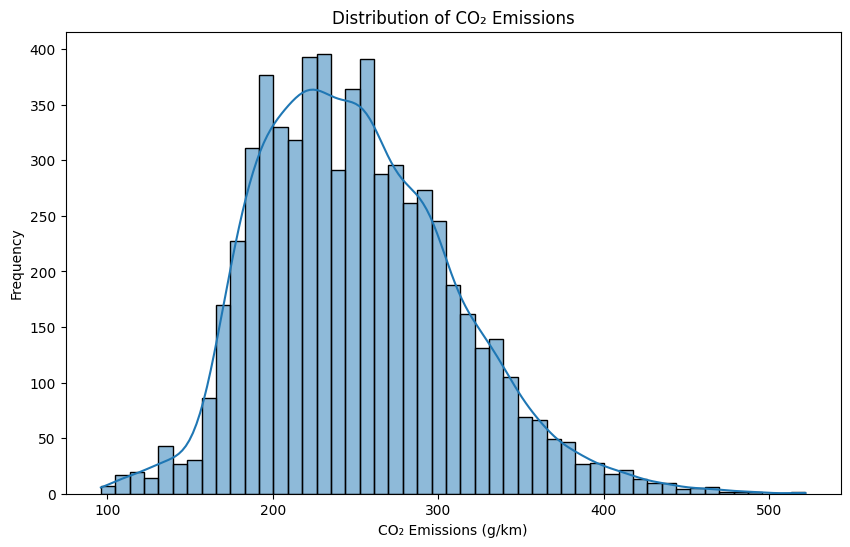

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df[target_col],
    kde=True
)

plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Frequency")

plt.show()

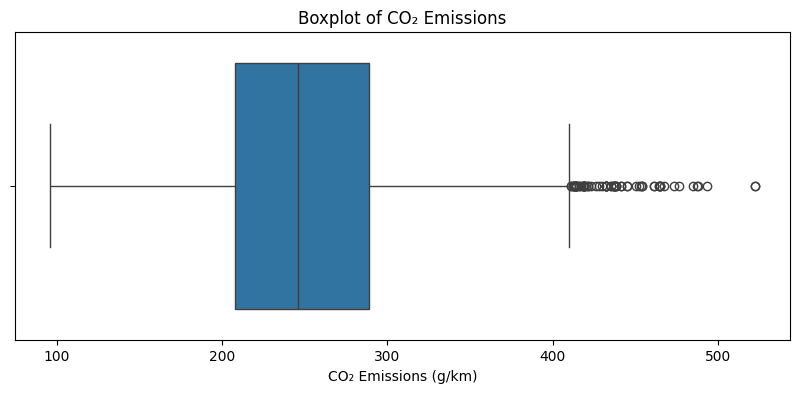

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df[target_col]
)

plt.title("Boxplot of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")

plt.show()

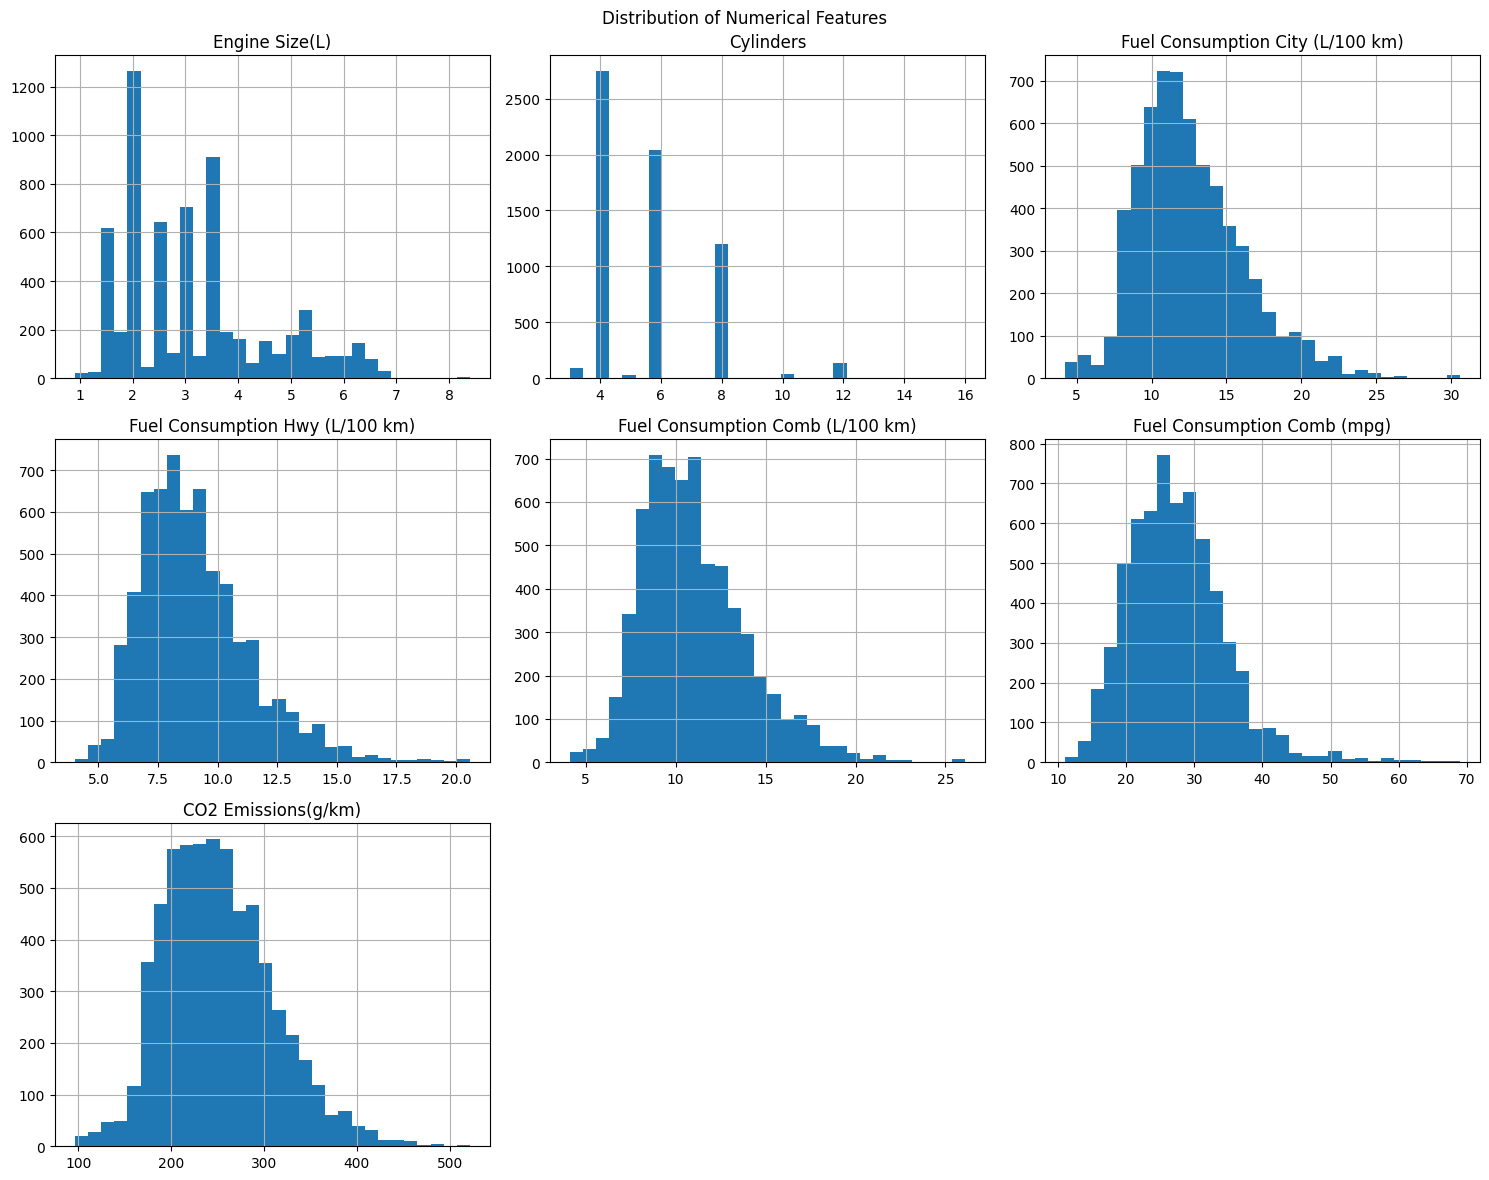

In [ ]:
df[numeric_columns].hist(
    figsize=(15,12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")

plt.tight_layout()
plt.show()

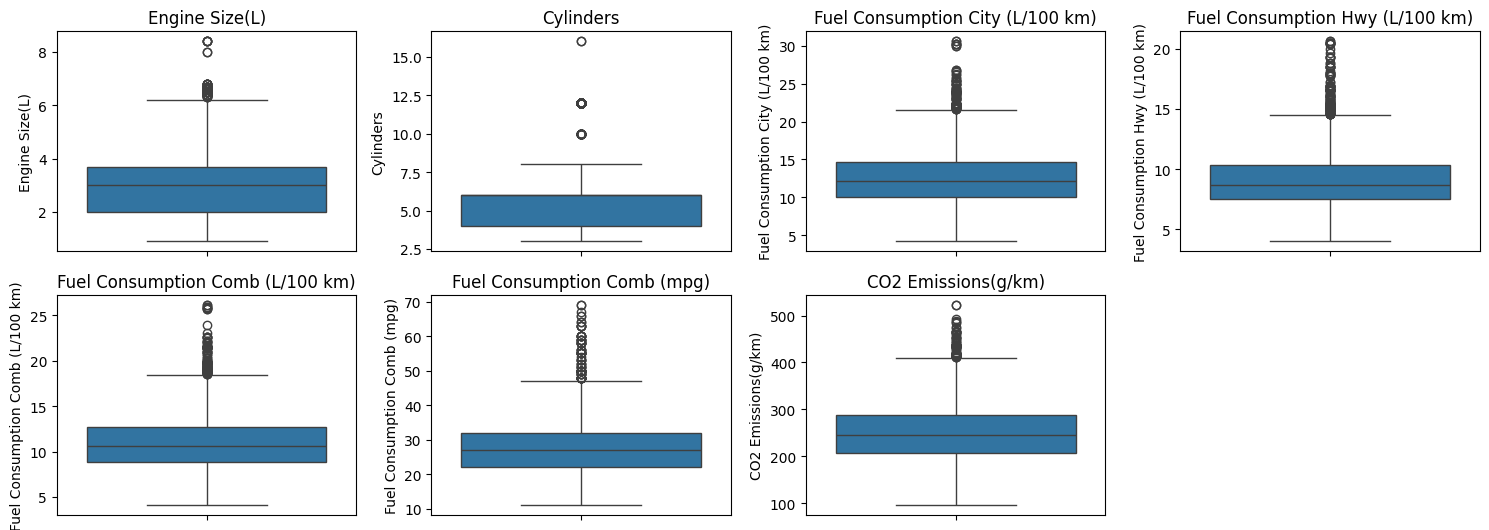

In [ ]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numeric_columns):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

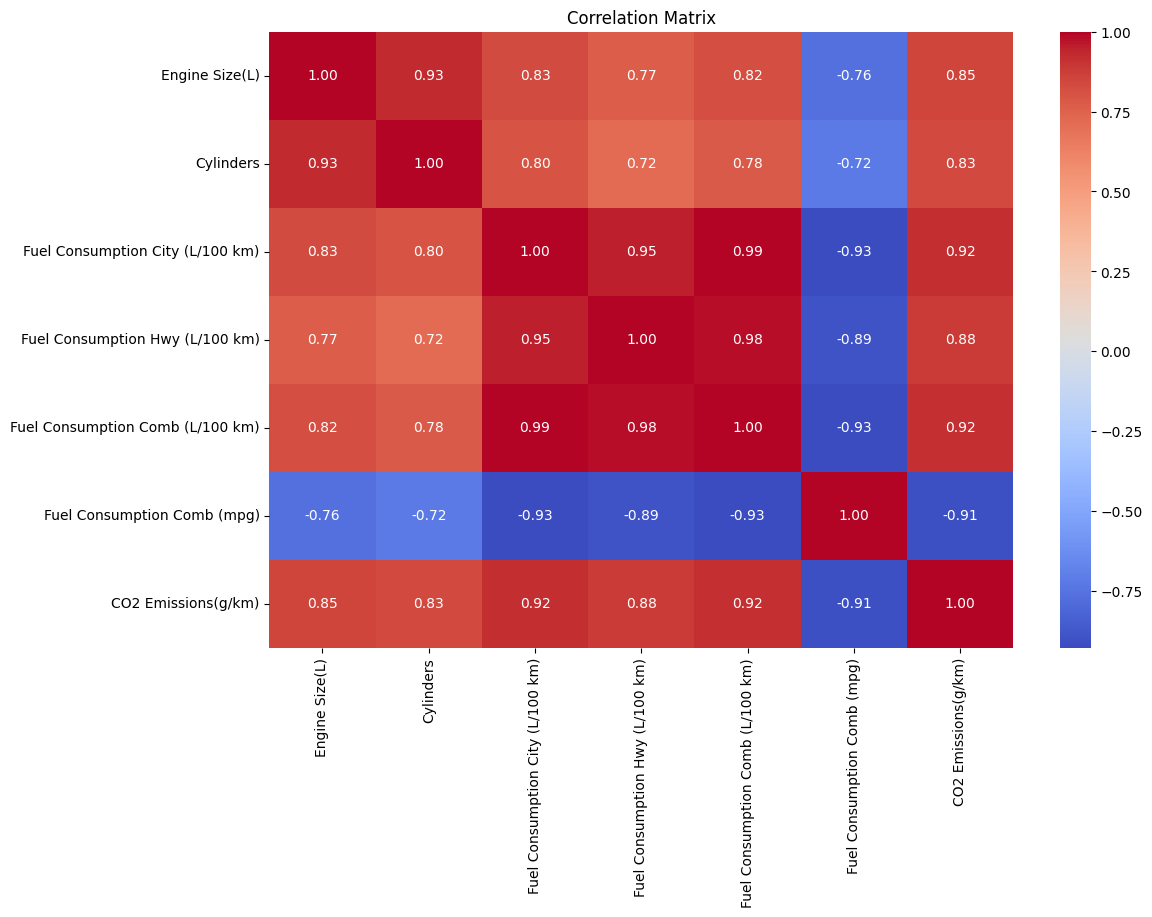

In [ ]:
plt.figure(figsize=(12,8))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
correlation_with_target = (
    df[numeric_columns]
    .corr()[target_col]
    .sort_values(ascending=False)
)

print(correlation_with_target)

CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.918756
Fuel Consumption Comb (L/100 km)    0.916840
Fuel Consumption Hwy (L/100 km)     0.883424
Engine Size(L)                      0.854802
Cylinders                           0.834687
Fuel Consumption Comb (mpg)        -0.906783
Name: CO2 Emissions(g/km), dtype: float64


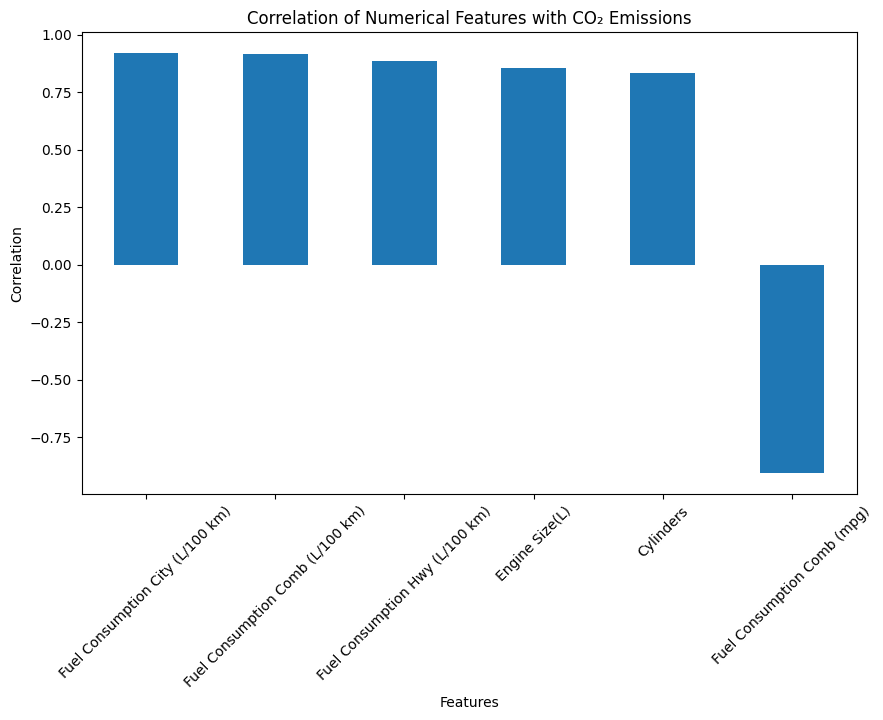

In [ ]:
plt.figure(figsize=(10,6))

correlation_with_target.drop(target_col).plot(
    kind='bar'
)

plt.title("Correlation of Numerical Features with CO₂ Emissions")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

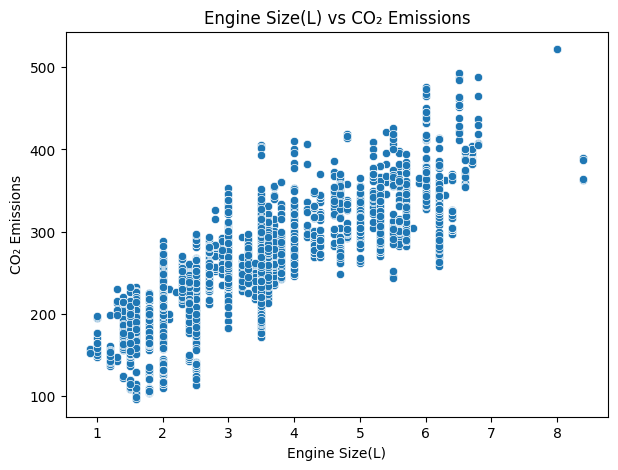

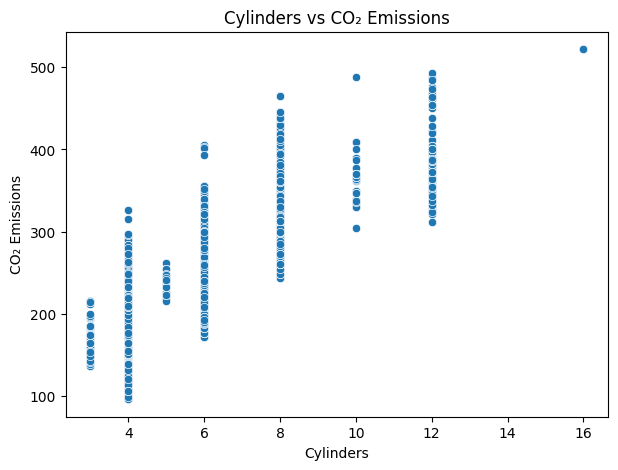

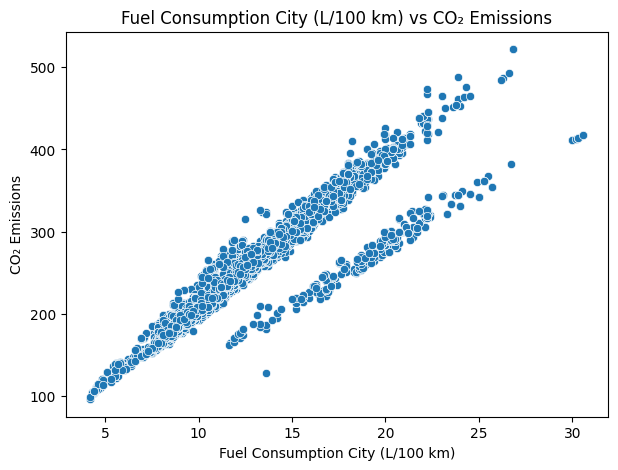

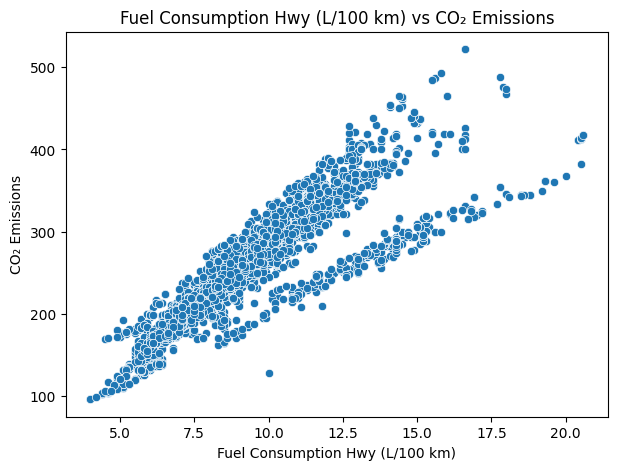

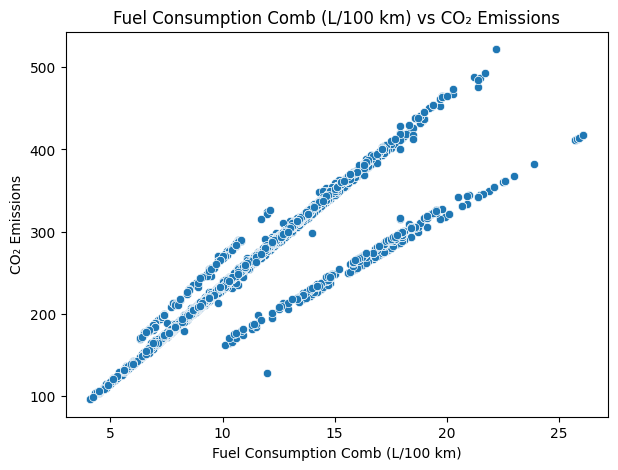

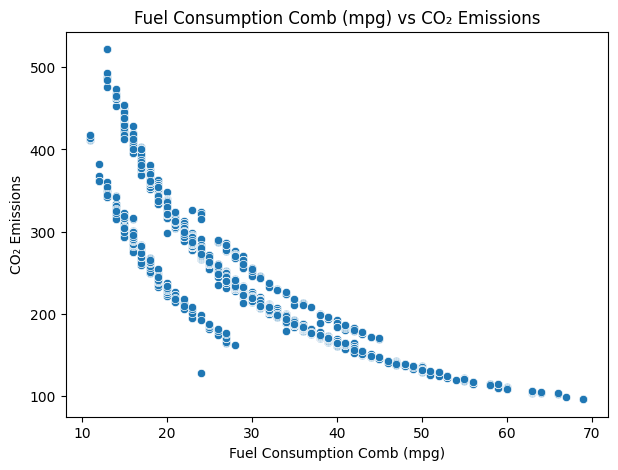

In [ ]:
important_features = [
    col for col in numeric_columns
    if col != target_col
]

for col in important_features:

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        data=df,
        x=col,
        y=target_col
    )

    plt.title(f"{col} vs CO₂ Emissions")
    plt.xlabel(col)
    plt.ylabel("CO₂ Emissions")

    plt.show()

In [ ]:
fuel_col = [c for c in df.columns if 'fuel' in c.lower() and 'type' in c.lower()][0]

print(df[fuel_col].value_counts())

Fuel Type
X    3039
Z    2765
E     330
D     147
N       1
Name: count, dtype: int64


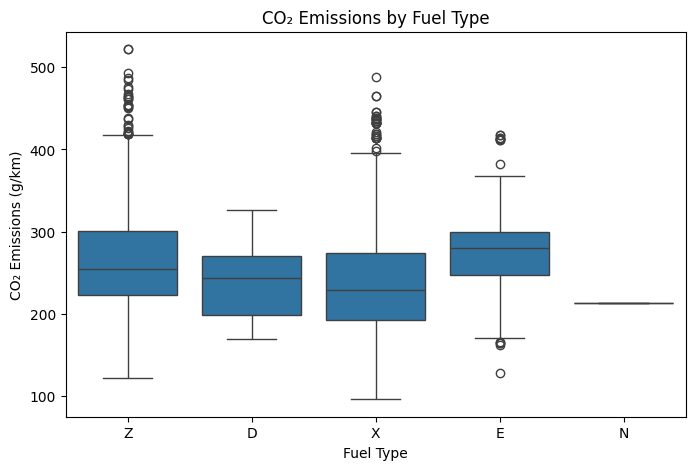

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x=fuel_col,
    y=target_col
)

plt.title("CO₂ Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("CO₂ Emissions (g/km)")

plt.show()

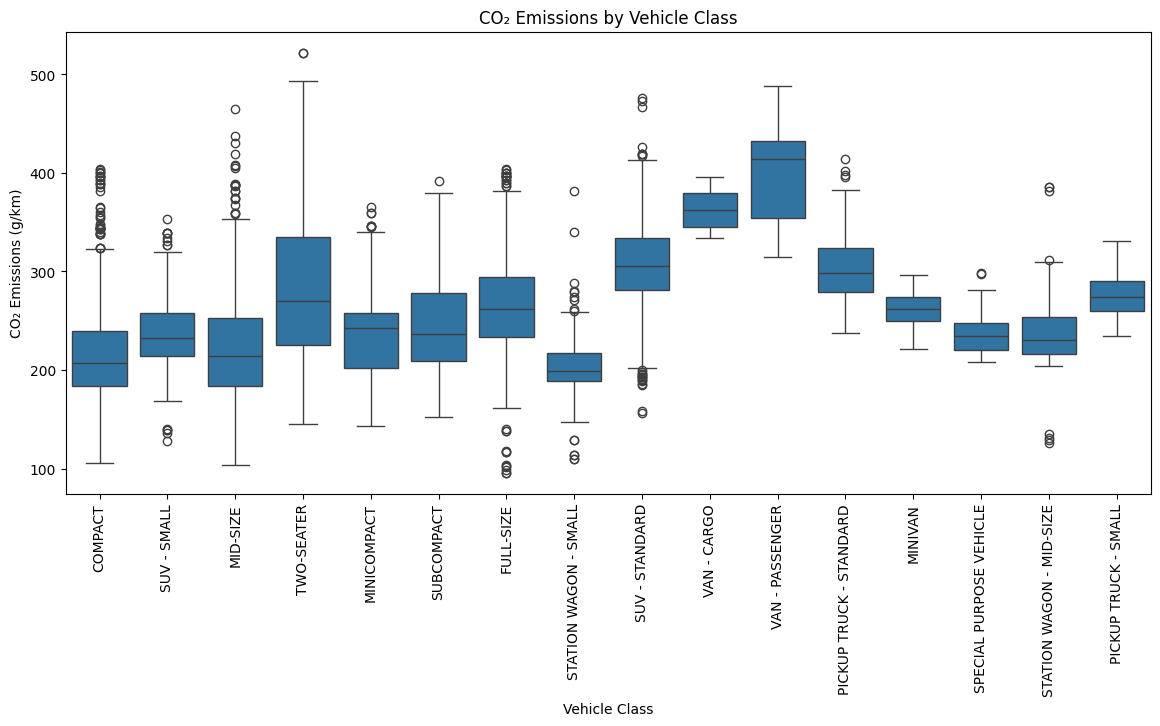

In [ ]:
vehicle_class_col = [
    c for c in df.columns
    if 'vehicle' in c.lower() and 'class' in c.lower()
]

if vehicle_class_col:

    vehicle_class_col = vehicle_class_col[0]

    plt.figure(figsize=(14,6))

    sns.boxplot(
        data=df,
        x=vehicle_class_col,
        y=target_col
    )

    plt.xticks(rotation=90)

    plt.title("CO₂ Emissions by Vehicle Class")
    plt.xlabel("Vehicle Class")
    plt.ylabel("CO₂ Emissions (g/km)")

    plt.show()

In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6282, 11)
y shape: (6282,)


In [ ]:
columns_to_drop = []

for col in X.columns:

    if X[col].dtype == 'object':

        unique_ratio = X[col].nunique() / len(X)

        if unique_ratio > 0.5:
            columns_to_drop.append(col)

print("Columns removed:")
print(columns_to_drop)

X = X.drop(columns=columns_to_drop)

Columns removed:
[]


In [ ]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include='object'
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)']

Categorical features:
['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5025, 11)
Testing data: (1257, 11)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [ ]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
gb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [ ]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return {
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

In [ ]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

results = []

results.append(
    evaluate_model(
        'Linear Regression',
        y_test,
        y_pred_linear
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        y_pred_rf
    )
)

results.append(
    evaluate_model(
        'Gradient Boosting',
        y_test,
        y_pred_gb
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,3.575674,31.751880,5.634881,0.991201
1,Random Forest,2.172259,15.514849,3.938889,0.995701
2,Gradient Boosting,2.685821,17.474003,4.180192,0.995158


In [ ]:
results_df.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
1,Random Forest,2.172259,15.514849,3.938889,0.995701
2,Gradient Boosting,2.685821,17.474003,4.180192,0.995158
0,Linear Regression,3.575674,31.751880,5.634881,0.991201


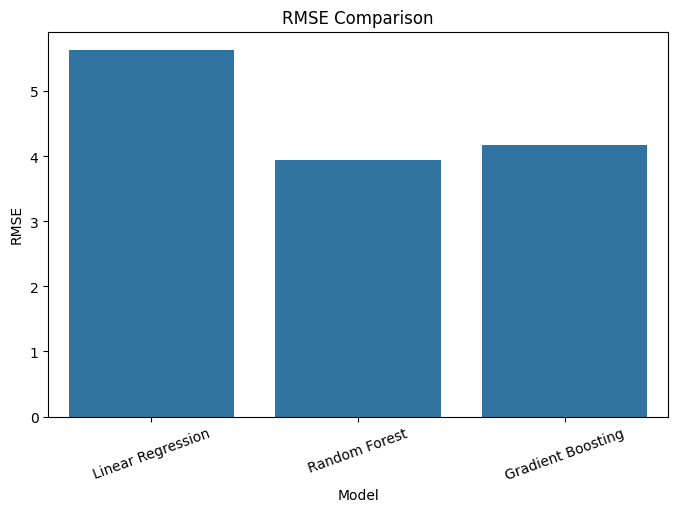

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE'
)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

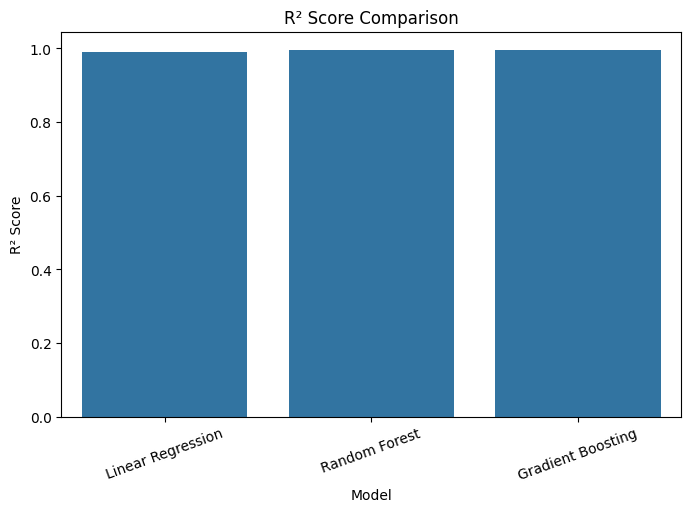

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title("R² Score Comparison")

plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

In [ ]:
best_model_name = results_df.loc[
    results_df['R2 Score'].idxmax(),
    'Model'
]

print("Best model:", best_model_name)

Best model: Random Forest


In [ ]:
predictions = {
    'Linear Regression': y_pred_linear,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}

best_predictions = predictions[best_model_name]

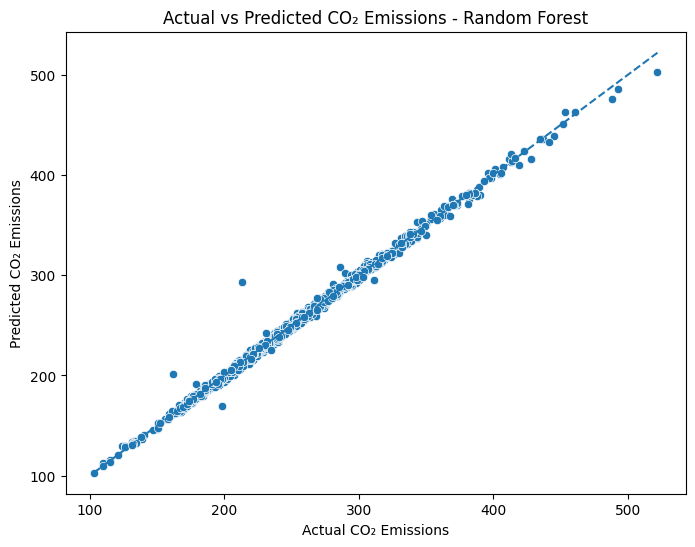

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")

plt.title(
    f"Actual vs Predicted CO₂ Emissions - {best_model_name}"
)

# Perfect prediction line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.show()

In [ ]:
residuals = y_test - best_predictions

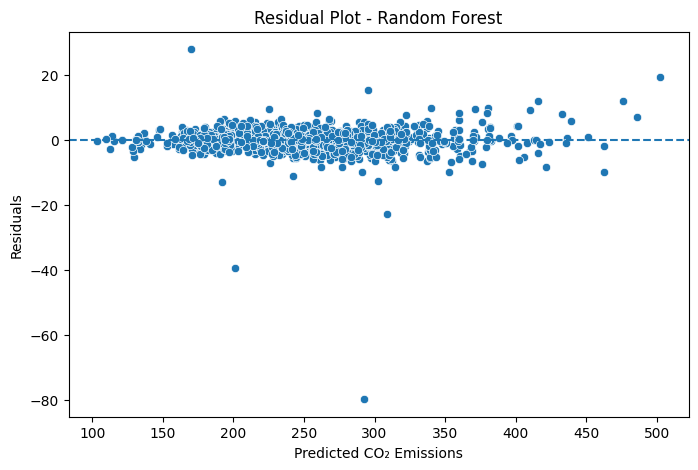

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted CO₂ Emissions")
plt.ylabel("Residuals")

plt.title(
    f"Residual Plot - {best_model_name}"
)

plt.show()

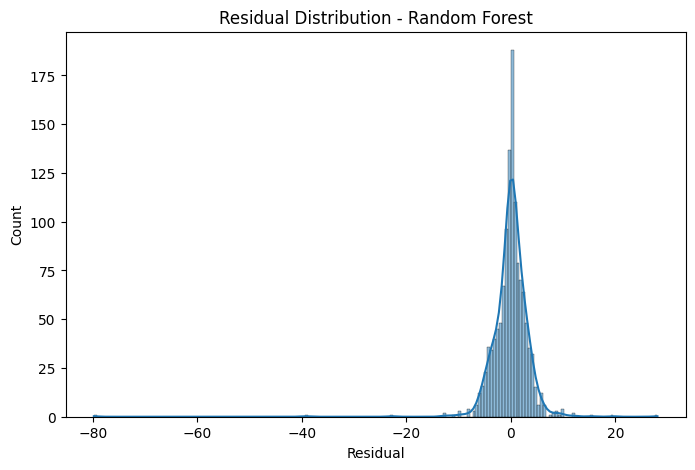

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    f"Residual Distribution - {best_model_name}"
)

plt.xlabel("Residual")

plt.show()

In [ ]:
rf_preprocessor = rf_model.named_steps['preprocessor']

feature_names = rf_preprocessor.get_feature_names_out()

rf_regressor = rf_model.named_steps['model']

importance = rf_regressor.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,num__Fuel Consumption Comb (L/100 km),0.792537
5,num__Fuel Consumption Comb (mpg),0.134288
1984,cat__Fuel Type_E,0.050269
2,num__Fuel Consumption City (L/100 km),0.010445
1983,cat__Fuel Type_D,0.005053
0,num__Engine Size(L),0.003410
3,num__Fuel Consumption Hwy (L/100 km),0.001365
889,cat__Model_FOCUS FFV,0.000561
1,num__Cylinders,0.000375
1972,cat__Transmission_AS7,0.000082


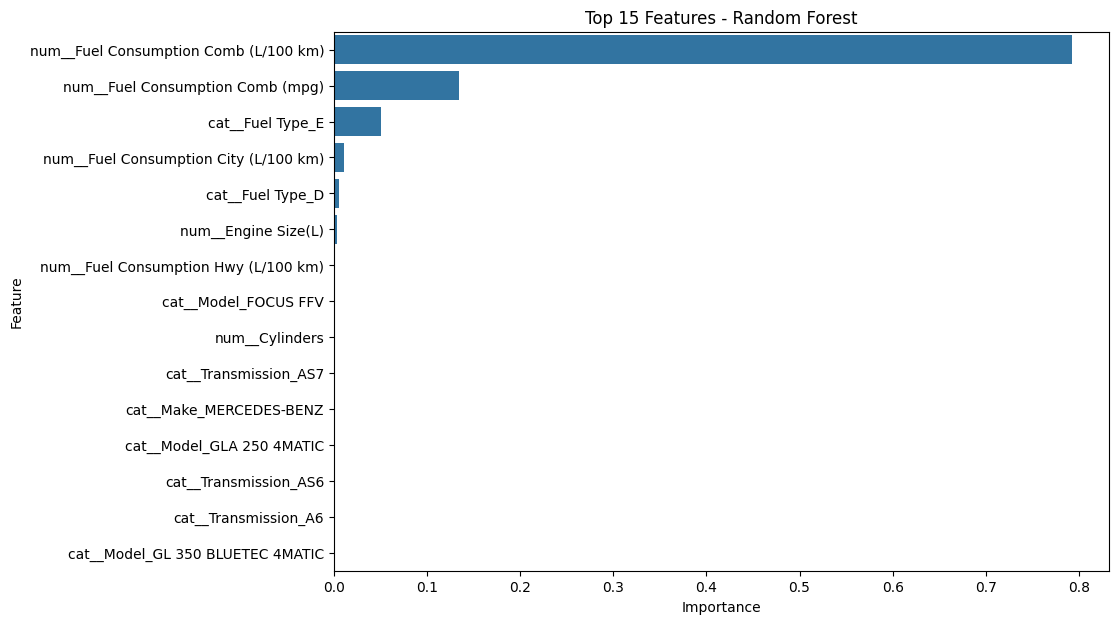

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Features - Random Forest")

plt.show()